In [4]:
import numpy as np
import random

In [5]:
tinyllama_scores = [0.78, 0.80, 0.81, 0.79, 0.77, 0.82, 0.80, 0.79, 0.78, 0.81]

qwen_scores = [0.85, 0.86, 0.87, 0.84, 0.88, 0.86, 0.85, 0.87, 0.86, 0.85]

In [12]:
def bootstrap_ci(data, n_bootstrap=1000, alpha=0.05):

    means = []

    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))

    lower = np.percentile(means, 100 * alpha/2)
    upper = np.percentile(means, 100 * (1 - alpha/2))

    return np.mean(data), lower, upper

In [13]:
mean_tl, low_tl, up_tl = bootstrap_ci(tinyllama_scores)
mean_qw, low_qw, up_qw = bootstrap_ci(qwen_scores)
print(f"TinyLlama: mean={mean_tl:.3f}, 95% CI=[{low_tl:.3f}, {up_tl:.3f}]")
print(f"Qwen2.5: mean={mean_qw:.3f}, 95% CI=[{low_qw:.3f}, {up_qw:.3f}]")

TinyLlama: mean=0.795, 95% CI=[0.785, 0.804]
Qwen2.5: mean=0.859, 95% CI=[0.852, 0.866]


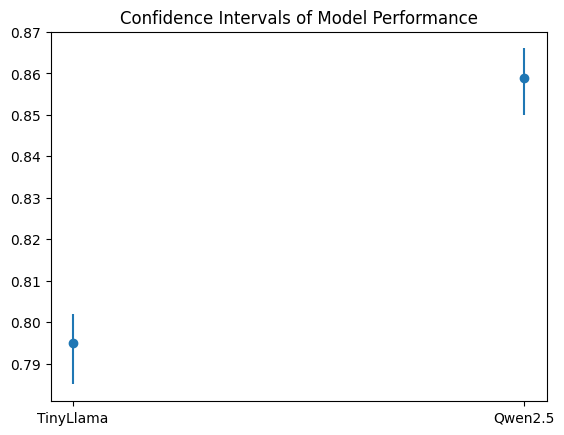

In [14]:
import matplotlib.pyplot as plt

models=["TinyLlama", "Qwen2.5"]
means=[mean_tl, mean_qw]
errors=[
    [mean_tl-low_tl,up_tl-mean_tl],
    [mean_qw-low_qw,up_qw-mean_qw]
]

plt.errorbar(models, means, yerr=errors, fmt='o')
plt.title("Confidence Intervals of Model Performance")
plt.show()
